## WHAM

used to get a single grand-canonical ensemble at a reference pH from a multiple set of constant-pH MD simulations

- from the grand-canonical ensemble in output I can extract the canonical ensembles, one for each protonation state

In [1]:
import sys
import numpy as np
import scipy
from scipy.optimize import curve_fit

# import plumed
import math
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.cm as cm             # color map
from cycler import cycler
    
plt.style.use('tableau-colorblind10')
name = "viridis"

cmap = plt.colormaps[name]
import os     # operating system interface
Dir     = os.getcwd()   # get current working directory

In [2]:
# import plumed  # plumed is used only for plumed.read_as_pandas, why don't use pandas instead?
import bussilab

## Get Protonation Data

In [3]:
# First we create a pandas dataframe for time and protonation states
protdf    = pd.DataFrame(columns=['Time','Protonation'])
# We define the number of segments of our simulation
prots     = {}
pH_values = ['03.00','03.50','04.00']
# We define the frequency of protonation as in the CpHMD settings (20ps)
taup      = 20

# Create a dictionary for the data
prots = {"pH":[],"Time":[],"Protonation":[]}

# We iterate through each pH
for pH in pH_values:
    # Then for each segment
    # Get the occ files from the data folder
    path = "Simulation-data/A3mer/"
    itemList =  os.listdir(path)
    # Iterate through each .occ file to obtain the protonation states
    for file in itemList:
        c=0
        if ".occ" in file and pH in file:
            with open(path+file) as f:
                for line in f:
                    c+=1
                    time = c*20
                    # Save the time, pH and protonation state
                    prots["Time"].append(int(time))
                    prots["pH"].append(pH)
                    prots["Protonation"].append(float(line.strip()))
                    time += taup
    
protdf = pd.DataFrame.from_dict(prots,orient='columns')
protdf.reset_index(inplace=True)
print(protdf)



         index     pH     Time  Protonation
0            0  03.00       20          0.0
1            1  03.00       40          1.0
2            2  03.00       60          1.0
3            3  03.00       80          0.0
4            4  03.00      100          0.0
...        ...    ...      ...          ...
224995  224995  04.00  1499920          1.0
224996  224996  04.00  1499940          1.0
224997  224997  04.00  1499960          1.0
224998  224998  04.00  1499980          0.0
224999  224999  04.00  1500000          0.0

[225000 rows x 4 columns]


## Do the WHAM

In [21]:
# This is a function to process the result and obtain normalized weights of each frame
# at arbitrary pH

def compute_weights(N, pH, logW):
    logW -= np.log(10)*pH*N
    logW -= np.max(logW)
    weights = np.exp(logW)
    weights /= np.sum(weights)
    return weights



In [5]:
protdf

,index,pH,Time,Protonation
0,0,03.00,20,0.0
1,1,03.00,40,1.0
2,2,03.00,60,1.0
3,3,03.00,80,0.0
4,4,03.00,100,0.0
...,...,...,...,...
224995,224995,04.00,1499920,1.0
224996,224996,04.00,1499940,1.0
224997,224997,04.00,1499960,1.0
224998,224998,04.00,1499980,0.0


In [ ]:
df = pd.read_csv(f"{path}/TOTVAR_REWEIGHT_" + str(pH), sep=' ')[2:]



df

,nan,time,chi,eRMSD,metad.bias,nan2
2,NaN,0.000000,-1.050246,1.054092,150.725172,NaN
3,NaN,1.000000,-1.043169,1.175289,152.966776,NaN
4,NaN,2.000000,-0.292339,1.103215,140.782311,NaN
5,NaN,3.000000,-0.155172,1.130084,139.283746,NaN
6,NaN,4.000000,-0.016830,1.108039,137.712633,NaN
...,...,...,...,...,...,...
112497,NaN,112495.000000,-0.931121,1.180245,152.520811,NaN
112498,NaN,112496.000000,-0.388632,1.166304,143.931291,NaN
112499,NaN,112497.000000,-0.803565,1.224548,150.930651,NaN
112500,NaN,112498.000000,-0.592147,1.194844,148.213712,NaN


In [ ]:
# Create necessary lists
N       = []
colpH   = []
biaspH  = []
KbT = 2.5
# Define the pH arrays
pH_values = ["03.00","03.50","04.00"] # 
pH_array  = np.array([3.0,3.5,4.0])

path="Simulation-data/A3mer/"
# Iterate through each pH
N = []
for pH in pH_values:
    # Load each output of the concatenated trajectories as a distinct pH dataframe 
    # df    = plumed.read_as_pandas(f"{path}/TOTVAR_REWEIGHT_" + str(pH))
    df = pd.read_csv(f"{path}/TOTVAR_REWEIGHT_" + str(pH), sep=' ')[2:]
    df.columns = ['nan', 'time', 'chi', 'eRMSD', 'metad.bias', 'nan2']
    print(df)
    # Extract the bias and store it
    colpH = np.array(df["metad.bias"])
    biaspH.append(colpH)
    N.append(protdf["Protonation"].loc[(protdf["pH"]==pH) & (protdf["Time"]>=750000) & (protdf["Time"]<1500000)])
# Be careful with the sorting of the data to avoid mismatches
# Define the protonation array using the stored data in the rewprot dataframe
N = np.concatenate(N)

# Transpose the array to match the matrix
biaspH = np.array(biaspH).T 

# Correct the bias matrix with the pH-dependent protonation contribution
# This is done by doing the dot product of each bias with the correspoding protonation data
# and pH. 

# The energy contribution is given by: log(10)*pH_k*prot_i 
# and that is applied to each corresponding entry (i,k) of the matrix 
bias = np.outer(N,(np.log(10)*pH_array))+biaspH/KbT
# Get the array length to apply a weight based on the trajectory length
# This will adjust the contribution in case of differently lengthed trajectories
lpH1 = len(np.array(protdf["Protonation"].loc[(protdf["pH"]=="03.00")])) 
lpH2 = len(np.array(protdf["Protonation"].loc[(protdf["pH"]=="03.50")])) 
lpH3 = len(np.array(protdf["Protonation"].loc[(protdf["pH"]=="04.00")])) 
min = np.amin([lpH1,lpH2,lpH3])

# Get the relative trj length for each pH value
rtrj1 = lpH1/min
rtrj2 = lpH2/min
rtrj3 = lpH3/min



        nan           time        chi     eRMSD  metad.bias  nan2
2       NaN       0.000000  -1.050246  1.054092  150.217871   NaN
3       NaN       1.000000  -1.043169  1.175289  152.103092   NaN
4       NaN       2.000000  -0.292339  1.103215  141.535634   NaN
5       NaN       3.000000  -0.155172  1.130084  140.146541   NaN
6       NaN       4.000000  -0.016830  1.108039  138.211043   NaN
...     ...            ...        ...       ...         ...   ...
112497  NaN  112495.000000  -0.931121  1.180245  151.530464   NaN
112498  NaN  112496.000000  -0.388632  1.166304  144.353851   NaN
112499  NaN  112497.000000  -0.803565  1.224548  149.447498   NaN
112500  NaN  112498.000000  -0.592147  1.194844  147.548555   NaN
112501  NaN  112499.000000  -0.692991  1.196314  149.011248   NaN

[112500 rows x 6 columns]
        nan           time        chi     eRMSD  metad.bias  nan2
2       NaN       0.000000  -1.050246  1.054092  149.231675   NaN
3       NaN       1.000000  -1.043169  1.175289  

In [15]:
# Get the final weights based on the bias matrix
wham_result = bussilab.wham.wham(bias, normalize=False, method='minimize', traj_weight=[rtrj1, rtrj2, rtrj3])


In [19]:
wham_result.logW.shape

(112500,)

Compute weights

In [22]:
# Define the desired pH range for the calculation
pH_array = np.arange(3.0,4.1,0.5)

# Define necessary lists
weights   = []

# Iterate through each pH value of the defined range
for iter in pH_array:
            # Get the average protonation using the computed weights for the desired pH
            weights.append(compute_weights(N, iter, wham_result.logW))


 3.98


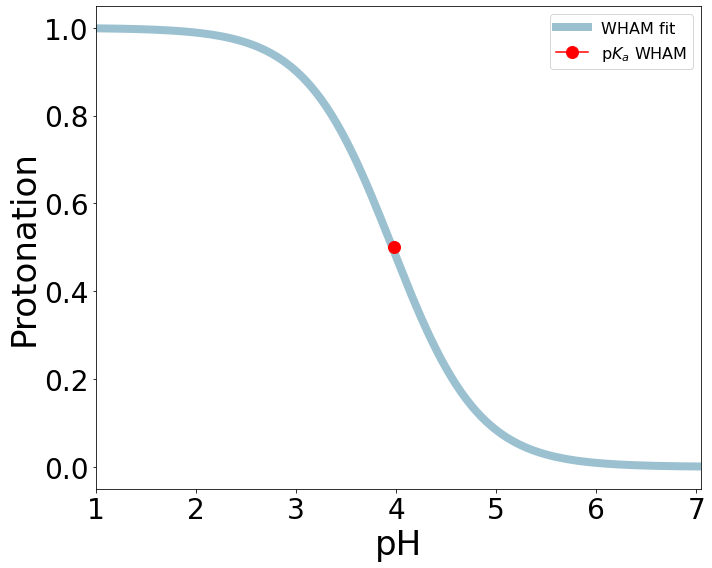

In [14]:


# Define the desired pH range for the calculation
pH_array = np.arange(1.0,10.2,0.05)

# Define necessary lists
rprots   = []

# Iterate through each pH value of the defined range
for iter in pH_array:
            # Get the average protonation using the computed weights for the desired pH
            avx = np.average(N,weights=compute_weights(N,iter,w))
            rprots.append(avx)

# Compute the absolute difference relative to the midtration point
rprots    = np.array(rprots)
min_diffs = np.abs(rprots - 0.5)
 
 # Get the indices of the two smallest differences
indices = np.argsort(min_diffs)[:2]
 
 # Return the corresponding values
closest = pH_array[indices]
pKa_fit = np.mean(closest) 
pKa_fit = '{:5.2f}'.format(pKa_fit)
print(pKa_fit)

#
plt.figure(figsize=(10,8))
#
plt.plot(pH_array,rprots,'#9bc1d1',linewidth=8,label="WHAM fit")
plt.plot(float(pKa_fit),0.5,markersize=12,marker="o",color="red",label="p$\it{K}_a$ WHAM")
plt.xlabel("pH",fontsize=34)
plt.ylabel("Protonation",fontsize=34)
plt.xticks(np.arange(1.0,10.1,step=1),fontsize=28)
plt.yticks(np.arange(0,1.2,step=0.2),fontsize=28)
plt.xlim(1.0,7.05)

plt.legend(fontsize=16)
plt.tight_layout()
plt.show()



